<a href="https://colab.research.google.com/github/vodnalasuhas/DAA-CSE-C/blob/main/EXP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

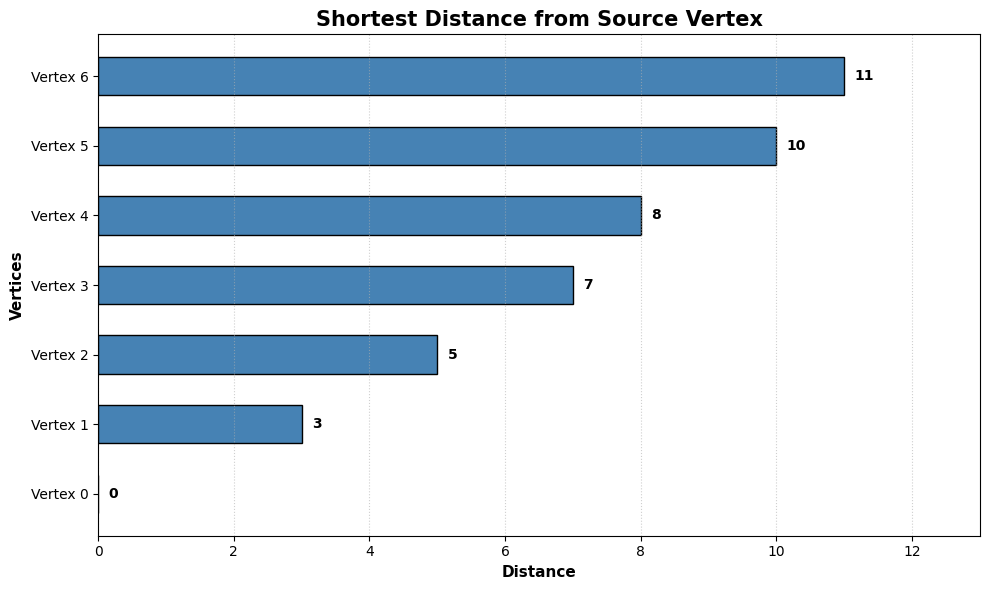

In [7]:
import heapq
import matplotlib.pyplot as plt

# -------------------- Dijkstra's Algorithm --------------------

def calculate_shortest_distance(network, source):

    shortest_distance = {}
    visited_nodes = set()
    priority_queue = []

    for node in network:
        shortest_distance[node] = float("inf")

    shortest_distance[source] = 0
    heapq.heappush(priority_queue, (0, source))

    while priority_queue:

        current_distance, current_node = heapq.heappop(priority_queue)

        if current_node in visited_nodes:
            continue

        visited_nodes.add(current_node)

        for adjacent_node, edge_weight in network[current_node]:

            updated_distance = current_distance + edge_weight

            if updated_distance < shortest_distance[adjacent_node]:
                shortest_distance[adjacent_node] = updated_distance
                heapq.heappush(
                    priority_queue,
                    (updated_distance, adjacent_node)
                )

    return shortest_distance


# -------------------- Graph Data --------------------

network = {
    0: [(1, 3), (2, 5)],
    1: [(3, 4), (4, 6)],
    2: [(1, 2), (5, 7)],
    3: [(4, 1), (6, 8)],
    4: [(5, 2), (6, 3)],
    5: [(6, 4)],
    6: []
}


# -------------------- Execute Algorithm --------------------

distances = calculate_shortest_distance(network, 0)

labels = [f"Vertex {i}" for i in sorted(distances.keys())]
values = [distances[i] for i in sorted(distances.keys())]


# -------------------- Visualization --------------------

plt.figure(figsize=(10, 6))

bars = plt.barh(
    labels,
    values,
    color="steelblue",
    edgecolor="black",
    height=0.55
)

for bar, value in zip(bars, values):

    plt.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Shortest Distance from Source Vertex",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Distance",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Vertices",
    fontsize=11,
    fontweight="bold"
)

plt.grid(axis="x", linestyle=":", alpha=0.6)

plt.xlim(0, max(values) + 2)

plt.tight_layout()
plt.show()